# Decision Tree

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics

# 1. Load data
# Make sure your CSV file is in the same folder as this script
df = pd.read_csv('clean_transactions_pandas.csv').dropna(subset=['actual_worth', 'procedure_area'])

# 2. Feature Engineering (Helping the models reach 90%)
df['price_per_sqft'] = df['actual_worth'] / df['procedure_area']
df['year'] = pd.to_datetime(df['instance_date']).dt.year
df['month'] = pd.to_datetime(df['instance_date']).dt.month

# 3. Create Target Classes (Low, Medium, High)
df['class'] = pd.qcut(df['actual_worth'], q=3, labels=[0, 1, 2])

# 4. Feature Selection
features = [
    'procedure_area', 'year', 'month', 'trans_group_en',
    'property_sub_type_en', 'area_name_en', 'master_project_en',
    'rooms_en', 'has_parking', 'reg_type_en', 'property_usage_en'
]

X = df[features].copy()
y = df['class']

# 5. Label Encoding (Categorical to Numerical)
le = LabelEncoder()
for col in X.select_dtypes(include=['object']).columns:
    X[col] = le.fit_transform(X[col].astype(str))

# 6. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# --- MODEL 1: THE DECISION TREE ---
# One single tree. Great for seeing the logic flow.
dt_model = DecisionTreeClassifier(max_depth=15, random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)
dt_acc = metrics.accuracy_score(y_test, dt_preds)

In [ ]:
# --- MODEL 2: THE RANDOM FOREST ---
# 100 trees working together to reduce errors.
rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_acc = metrics.accuracy_score(y_test, rf_preds)

In [ ]:
# 7. Print Results Comparison
print("="*35)
print(f"DECISION TREE ACCURACY: {dt_acc * 100:.2f}%")
print(f"RANDOM FOREST ACCURACY: {rf_acc * 100:.2f}%")
print("="*35)

DECISION TREE ACCURACY: 83.35%
RANDOM FOREST ACCURACY: 84.47%


In [ ]:
# Check both scores
train_acc = dt_model.score(X_train, y_train)
test_acc = dt_model.score(X_test, y_test)

print(f"Training Accuracy: {train_acc * 100:.2f}%")
print(f"Testing Accuracy: {test_acc * 100:.2f}%")

Training Accuracy: 82.10%
Testing Accuracy: 81.24%


In [ ]:
# Check both scores
train_acc = rf_model.score(X_train, y_train)
test_acc = rf_model.score(X_test, y_test)

print(f"Training Accuracy: {train_acc * 100:.2f}%")
print(f"Testing Accuracy: {test_acc * 100:.2f}%")

Training Accuracy: 82.01%
Testing Accuracy: 81.28%


/tmp/ipython-input-3800134491.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=scores, palette='magma')


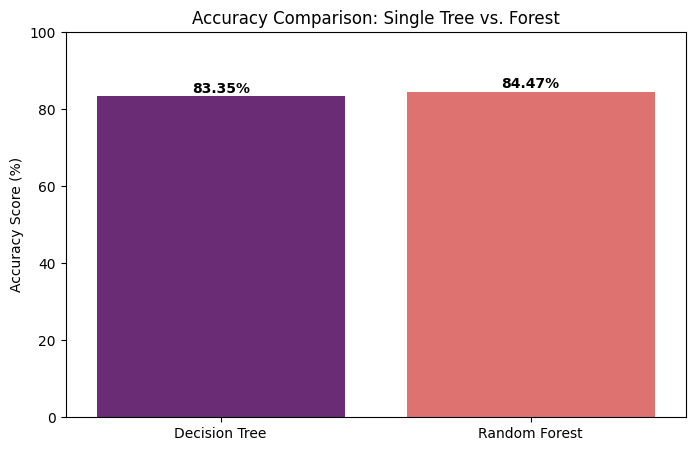

In [ ]:
# 8. Visualization: Accuracy Comparison Bar Chart
plt.figure(figsize=(8, 5))
models = ['Decision Tree', 'Random Forest']
scores = [dt_acc * 100, rf_acc * 100]
sns.barplot(x=models, y=scores, palette='magma')
plt.title('Accuracy Comparison: Single Tree vs. Forest')
plt.ylabel('Accuracy Score (%)')
plt.ylim(0, 100)
for i, v in enumerate(scores):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center', fontweight='bold')
plt.show()

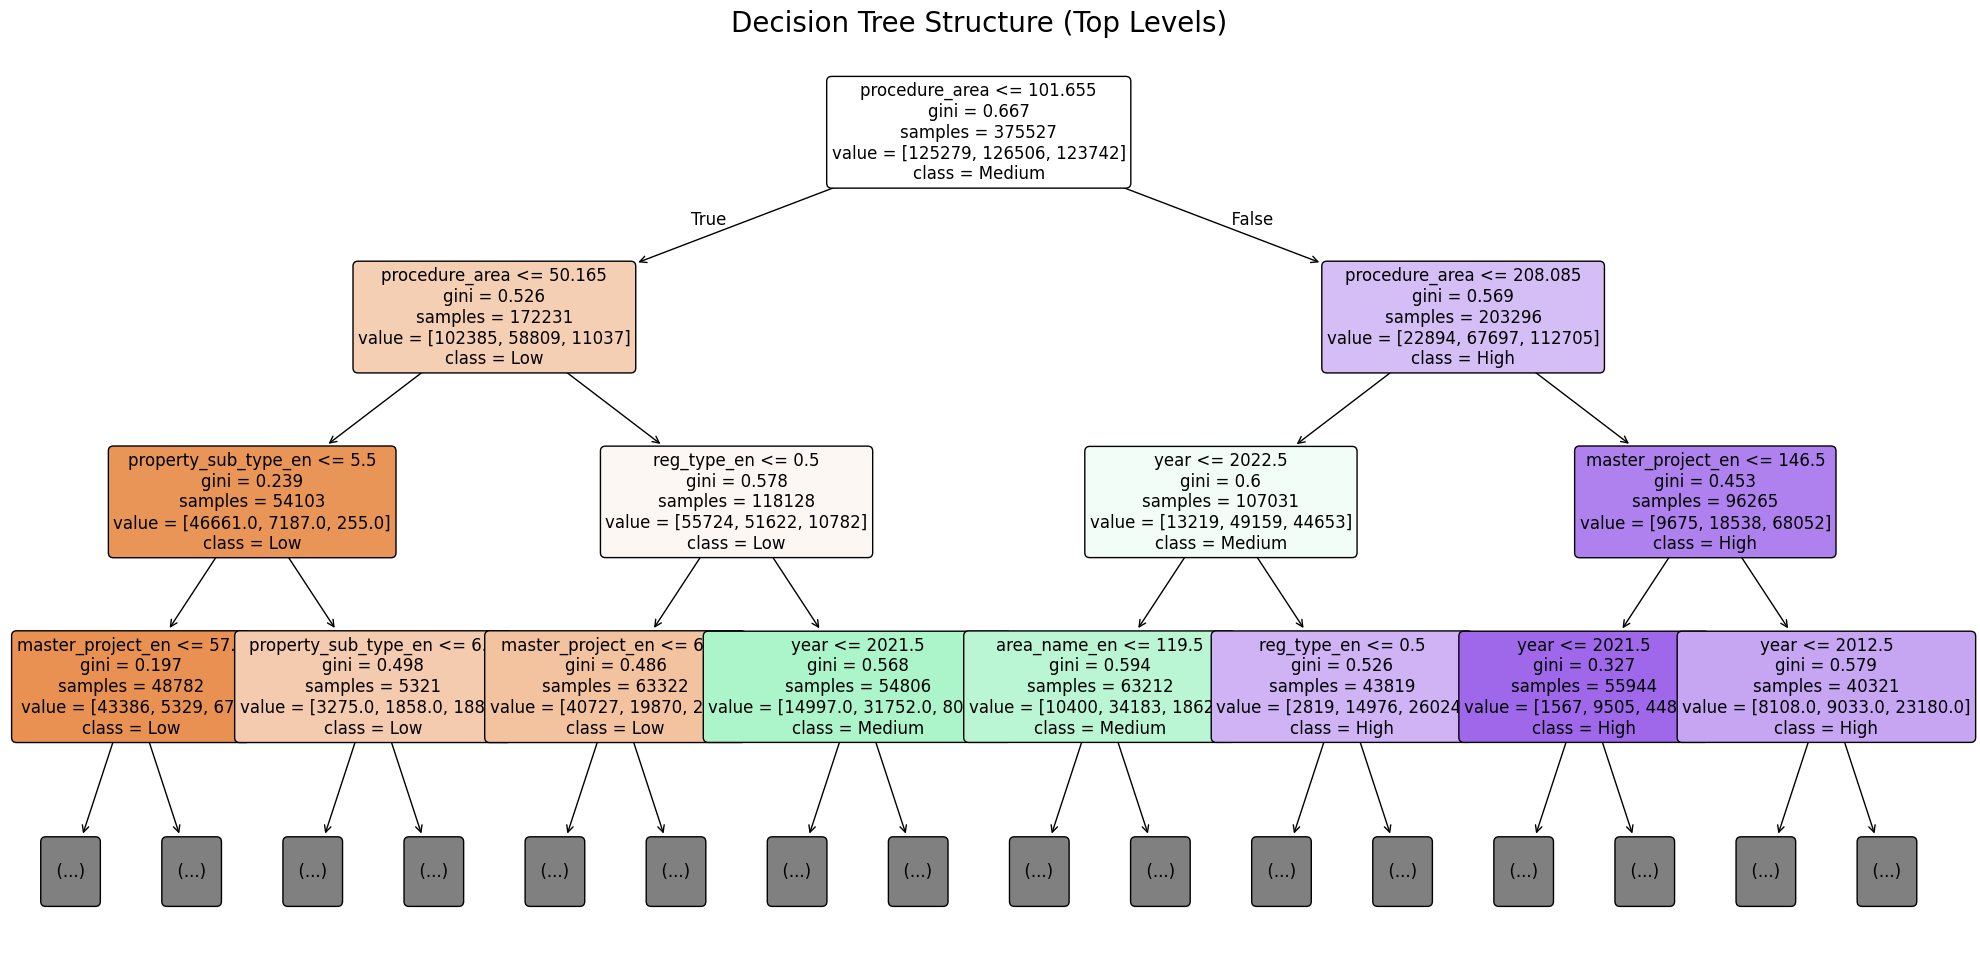

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Plotting the Decision Tree
plt.figure(figsize=(25,12))
plot_tree(dt_model,
          max_depth=3,               # Only show top 3 levels for readability
          feature_names=features,
          class_names=['Low', 'Medium', 'High'],
          filled=True,
          rounded=True,
          fontsize=12)
plt.title("Decision Tree Structure (Top Levels)", fontsize=20)
plt.show()

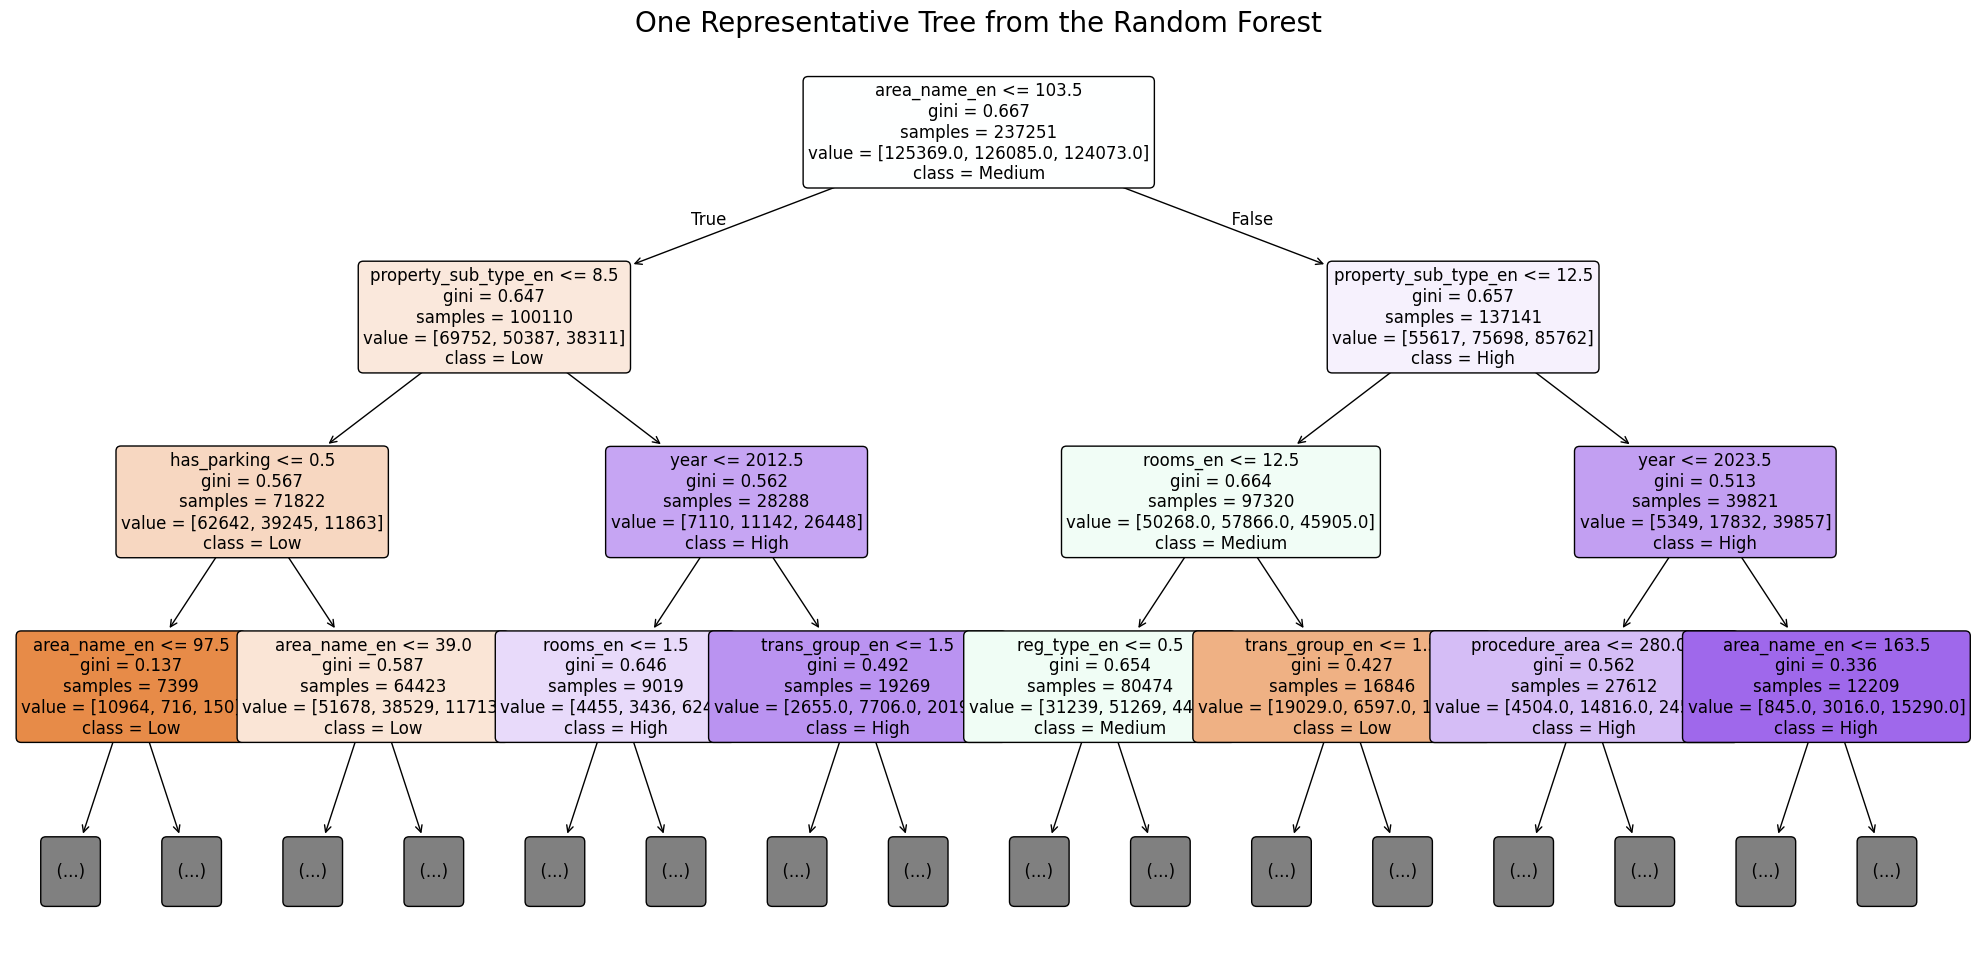

In [ ]:
# Plotting the first tree from the Random Forest
plt.figure(figsize=(25,12))
plot_tree(rf_model.estimators_[0],    # .estimators_[0] picks the first tree in the forest
          max_depth=3,
          feature_names=features,
          class_names=['Low', 'Medium', 'High'],
          filled=True,
          rounded=True,
          fontsize=12)
plt.title("One Representative Tree from the Random Forest", fontsize=20)
plt.show()